# 第 15 章数据可视化
使用第 14 章清洗结果的虚构教学快照。三个问题使用同一份数据，分别记录有效样本数。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / 'examples'))
from analysis import load_records, summarize
from explore_records import make_charts
from IPython.display import Image, display
frame = load_records('data/learning_records.csv')
print(frame.to_string(index=False))

record_id title  done  minutes    tag  source_row minutes_status
      L01    变量  True     20.0 python           2          known
      L02    循环 False     15.0 python           3          known
      L03    列表  True     <NA> python           4        missing
      L04    字典 False     <NA>     ai           6   invalid_text
      L05    集合  True     40.0     ai           7          known


In [2]:
result = summarize(frame)
print('全部、已知、未知', result['input_rows'], result['known_minutes_rows'], result['missing_minutes_rows'])
print('直方图计数', result['histogram_counts'])
print('均值、中位数', result['known_mean'], result['known_median'])

全部、已知、未知 5 3 2
直方图计数 [0, 1, 1, 0, 1]
均值、中位数 25.0 20.0


## 问题一，已知时长怎样分布
两条未知时长不进入直方图，区间边界明确保留。

绘图字体 Microsoft YaHei


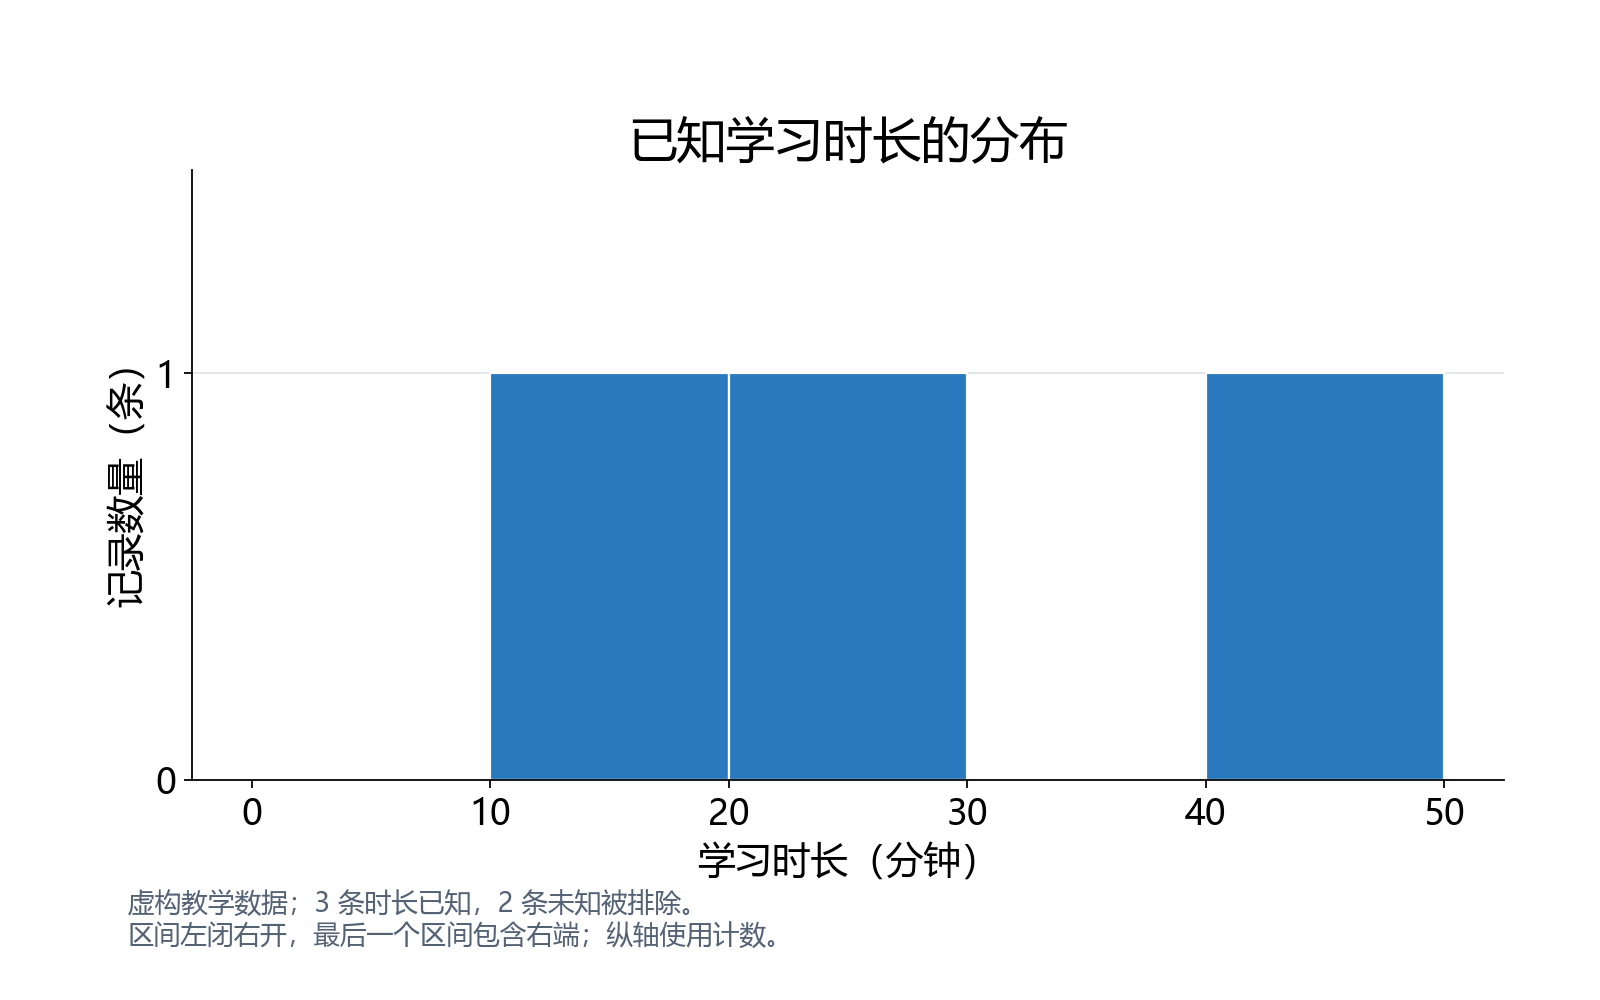

In [3]:
print('绘图字体', make_charts(frame, result, Path('assets')))
display(Image(filename='assets/minutes-histogram.png'))

## 问题二，不同标签完成多少条
分母是每组全部记录，未知时长不会删除完成状态。

   tag  records  completed  known_minutes  known_total  missing_minutes  completion_rate
    ai        2          1              1         40.0                1         0.500000
python        3          2              2         35.0                1         0.666667


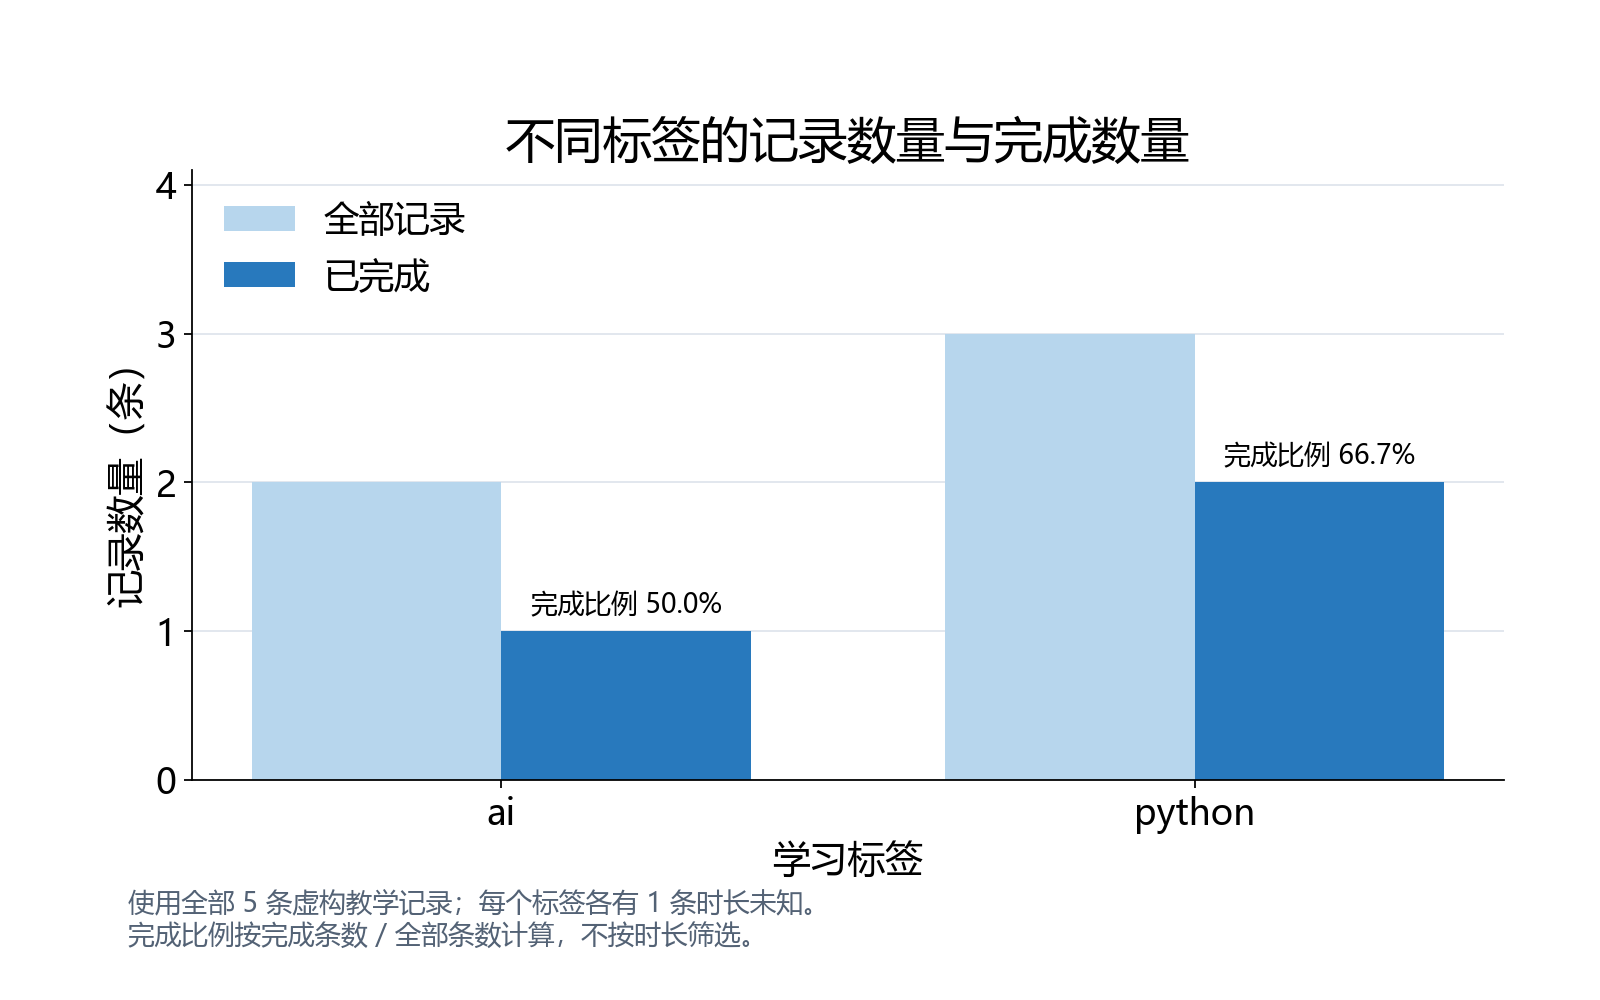

In [4]:
import pandas as pd
print(pd.DataFrame(result['groups']).to_string(index=False))
display(Image(filename='assets/tag-completion-bars.png'))

## 问题三，时长和完成状态怎样配对
只有三对数据，相关性不能解释为因果。

[{'record_id': 'L01', 'minutes': 20.0, 'done_code': 1}, {'record_id': 'L02', 'minutes': 15.0, 'done_code': 0}, {'record_id': 'L05', 'minutes': 40.0, 'done_code': 1}]
当前样本 Pearson r 0.6546536707079771


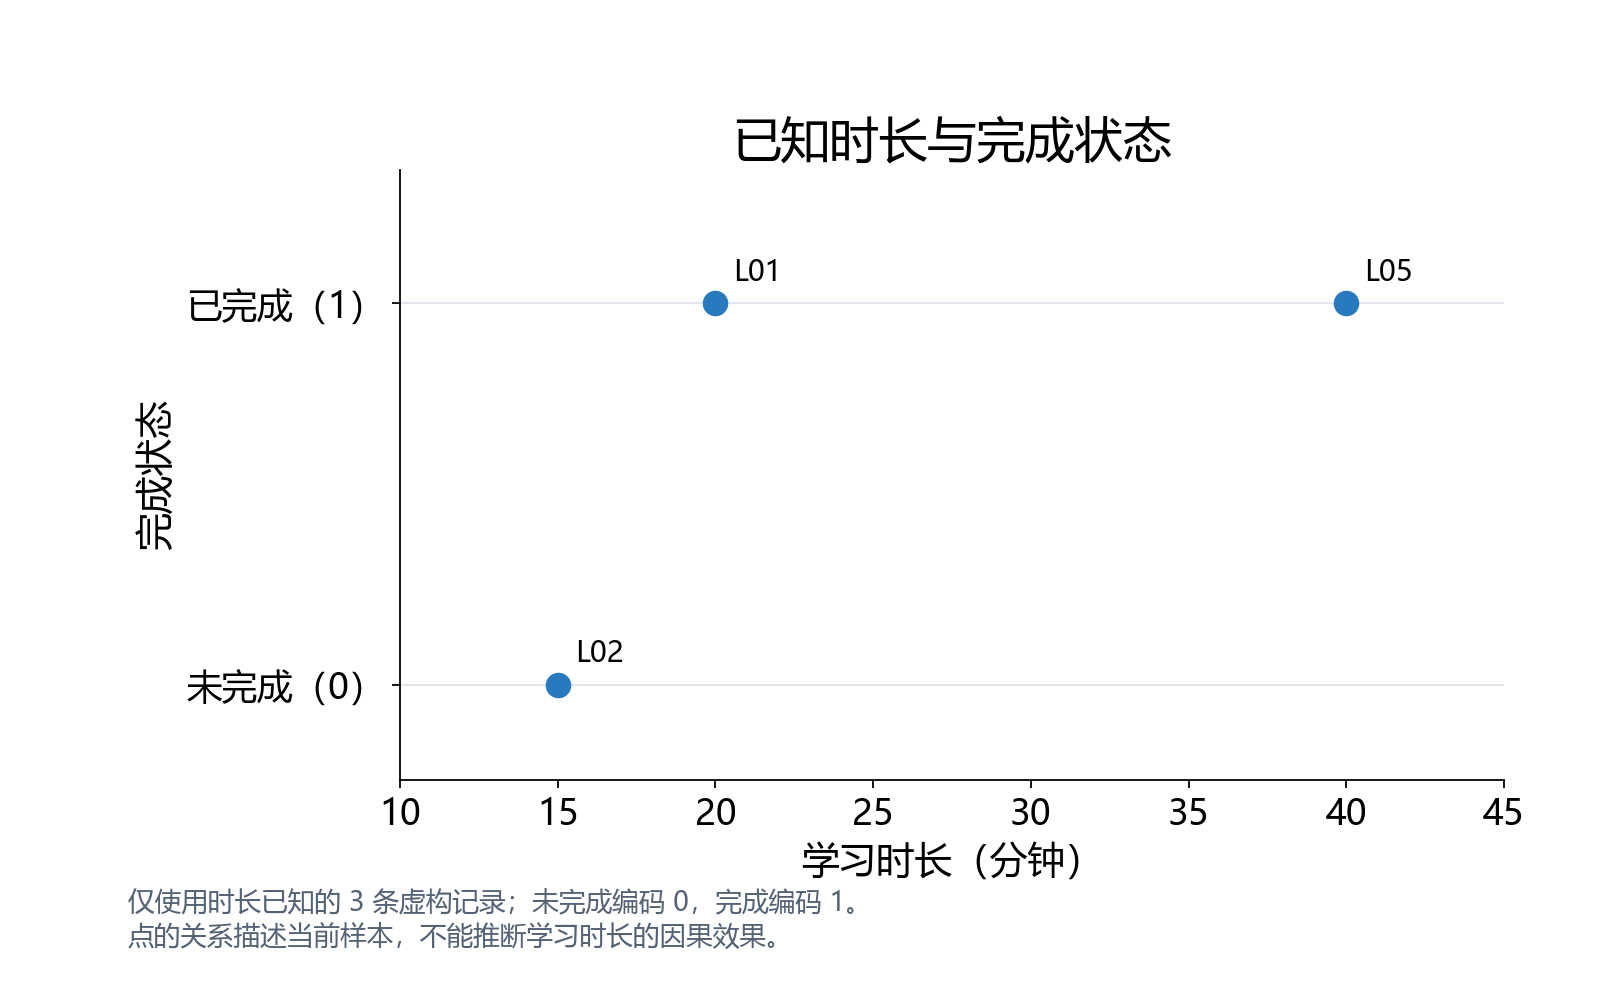

In [5]:
print(result['scatter_points'])
print('当前样本 Pearson r', result['pearson_r'])
display(Image(filename='assets/minutes-completion-scatter.png'))

## 独立练习
改用边界 0、20、40、60，先预测计数再运行。

In [6]:
import numpy as np
counts, edges = np.histogram(frame['minutes'].dropna().to_numpy(dtype=float), bins=[0, 20, 40, 60])
print(counts.tolist())
assert counts.tolist() == [1, 1, 1]

[1, 1, 1]
